
Running: FCFS

 FCFS Results
PID   Arrival   Burst   Pri   Wait    Turn    Complete  
--------------------------------------------------------
P1    0         10      3     0       10      10        
P2    1         1       1     9       10      11        
P3    2         2       3     9       11      13        
P4    3         1       4     10      11      14        
P5    4         5       2     10      15      19        
--------------------------------------------------------

Average Waiting Time: 7.60
Average Turnaround Time: 11.40


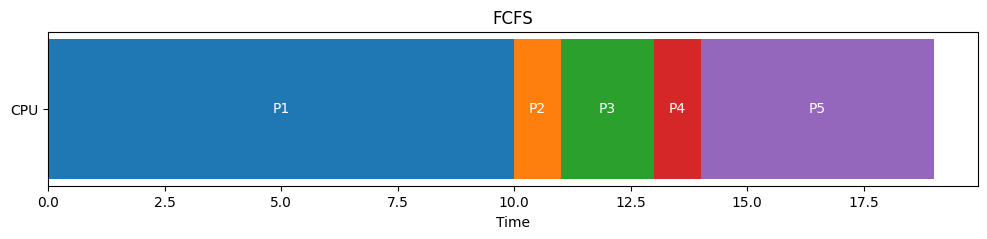


Running: SJF Non-Preemptive

 SJF Non-Preemptive Results
PID   Arrival   Burst   Pri   Wait    Turn    Complete  
--------------------------------------------------------
P1    0         10      3     0       10      10        
P2    1         1       1     9       10      11        
P3    2         2       3     10      12      14        
P4    3         1       4     8       9       12        
P5    4         5       2     10      15      19        
--------------------------------------------------------

Average Waiting Time: 7.40
Average Turnaround Time: 11.20


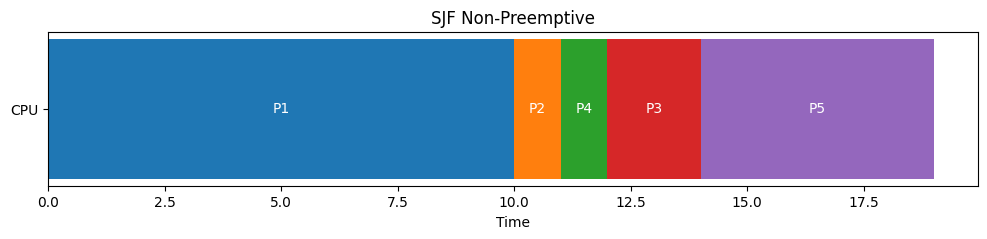


Running: Priority Non-Preemptive

 Priority Non-Preemptive Results
PID   Arrival   Burst   Pri   Wait    Turn    Complete  
--------------------------------------------------------
P1    0         10      3     0       10      10        
P2    1         1       1     9       10      11        
P3    2         2       3     14      16      18        
P4    3         1       4     15      16      19        
P5    4         5       2     7       12      16        
--------------------------------------------------------

Average Waiting Time: 9.00
Average Turnaround Time: 12.80


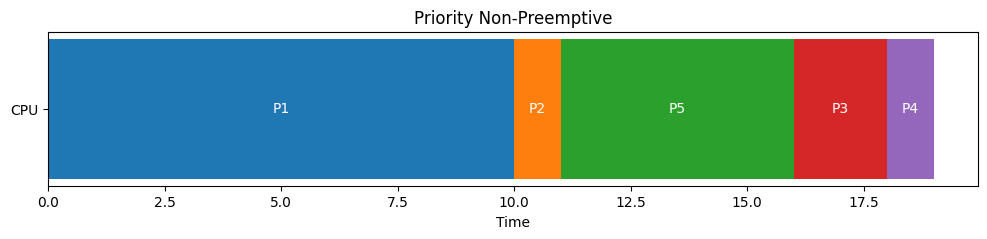


Running: Round Robin

 Round Robin Results
PID   Arrival   Burst   Pri   Wait    Turn    Complete  
--------------------------------------------------------
P1    0         10      3     9       19      19        
P2    1         1       1     1       2       3         
P3    2         2       3     1       3       5         
P4    3         1       4     2       3       6         
P5    4         5       2     6       11      15        
--------------------------------------------------------

Average Waiting Time: 3.80
Average Turnaround Time: 7.60


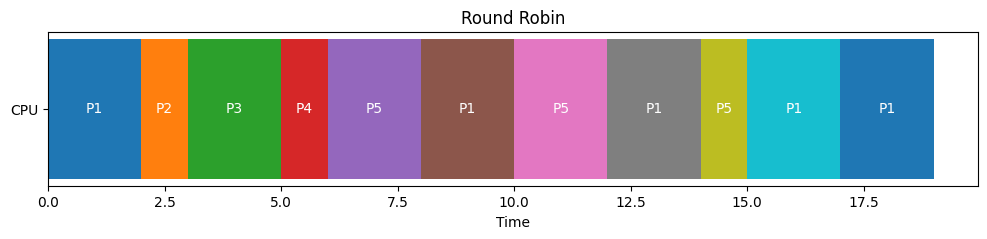


Running: SRTF

 SRTF Results
PID   Arrival   Burst   Pri   Wait    Turn    Complete  
--------------------------------------------------------
P1    0         10      3     9       19      19        
P2    1         1       1     0       1       2         
P3    2         2       3     0       2       4         
P4    3         1       4     1       2       5         
P5    4         5       2     1       6       10        
--------------------------------------------------------

Average Waiting Time: 2.20
Average Turnaround Time: 6.00


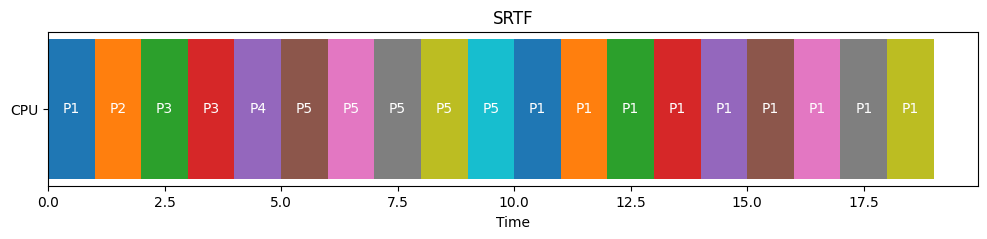


AVERAGE WAITING TIME COMPARISON
FCFS                          : 7.60
SJF Non-Preemptive            : 7.40
Priority Non-Preemptive       : 9.00
Round Robin                   : 3.80
SRTF                          : 2.20


In [1]:
# =========================
# CPU Scheduling Project
# Enhanced Version (No External Libraries)
# =========================
import matplotlib.pyplot as plt

# ============================================
# Process Class
# ============================================
class Process:
    def __init__(self, process_id, arrival_time, burst_time, priority=0):
        assert burst_time >= 0, "Burst time cannot be negative"
        assert arrival_time >= 0, "Arrival time cannot be negative"
        self.process_id = process_id
        self.arrival_time = arrival_time
        self.burst_time = burst_time
        self.priority = priority
        self.waiting_time = 0
        self.turnaround_time = 0
        self.completion_time = 0
        self.remaining_time = burst_time

    def reset_times(self):
        self.waiting_time = 0
        self.turnaround_time = 0
        self.completion_time = 0
        self.remaining_time = self.burst_time

# ============================================
# Scheduling Algorithms
# ============================================
class SchedulingAlgorithms:
    @staticmethod
    def fcfs(processes):
        t = 0
        gantt = []
        for p in sorted(processes, key=lambda x: x.arrival_time):
            if t < p.arrival_time:
                t = p.arrival_time
            gantt.append((p.process_id, t, t + p.burst_time))
            t += p.burst_time
            p.completion_time = t
            p.turnaround_time = p.completion_time - p.arrival_time
            p.waiting_time = p.turnaround_time - p.burst_time
        return processes, gantt

    @staticmethod
    def sjf_non_preemptive(processes):
        t = 0
        gantt = []
        completed = 0
        n = len(processes)
        processes_sorted = sorted(processes, key=lambda p: p.arrival_time)

        while completed < n:
            avail = [p for p in processes_sorted if p.arrival_time <= t and p.remaining_time > 0]
            if not avail:
                t += 1
                continue

            current = min(avail, key=lambda x: x.burst_time)
            gantt.append((current.process_id, t, t + current.burst_time))
            t += current.burst_time
            current.remaining_time = 0
            current.completion_time = t
            current.turnaround_time = current.completion_time - current.arrival_time
            current.waiting_time = current.turnaround_time - current.burst_time
            completed += 1

        return processes, gantt

    @staticmethod
    def priority_non_preemptive(processes):
        t = 0
        gantt = []
        completed = 0
        n = len(processes)

        while completed < n:
            avail = [p for p in processes if p.arrival_time <= t and p.remaining_time > 0]
            if not avail:
                t += 1
                continue

            current = min(avail, key=lambda p: p.priority)
            gantt.append((current.process_id, t, t + current.burst_time))
            t += current.burst_time
            current.remaining_time = 0
            current.completion_time = t
            current.turnaround_time = current.completion_time - current.arrival_time
            current.waiting_time = current.turnaround_time - current.burst_time
            completed += 1

        return processes, gantt

    @staticmethod
    def round_robin(processes, quantum=2):
        t = 0
        gantt = []
        queue = sorted(processes, key=lambda x: x.arrival_time)

        while True:
            done = True
            for p in queue:
                if p.remaining_time > 0:
                    done = False
                    if p.arrival_time > t:
                        t = p.arrival_time

                    exec_time = min(quantum, p.remaining_time)
                    gantt.append((p.process_id, t, t + exec_time))
                    t += exec_time
                    p.remaining_time -= exec_time

                    if p.remaining_time == 0:
                        p.completion_time = t
                        p.turnaround_time = t - p.arrival_time
                        p.waiting_time = p.turnaround_time - p.burst_time
            if done:
                break

        return processes, gantt

    @staticmethod
    def srtf(processes):
        t = 0
        gantt = []
        remaining = len(processes)
        processes_sorted = sorted(processes, key=lambda p: p.arrival_time)

        while remaining:
            available = [p for p in processes_sorted if p.arrival_time <= t and p.remaining_time > 0]
            if not available:
                t += 1
                continue

            current = min(available, key=lambda p: p.remaining_time)
            gantt.append((current.process_id, t, t + 1))
            current.remaining_time -= 1
            t += 1

            if current.remaining_time == 0:
                remaining -= 1
                current.completion_time = t
                current.turnaround_time = current.completion_time - current.arrival_time
                current.waiting_time = current.turnaround_time - current.burst_time

        return processes, gantt

# ============================================
# Performance Analyzer
# ============================================
class PerformanceAnalyzer:
    @staticmethod
    def calculate_average_waiting_time(processes):
        """Calculate and return average waiting time"""
        total_waiting = sum(p.waiting_time for p in processes)
        return total_waiting / len(processes) if processes else 0

    @staticmethod
    def calculate_average_turnaround_time(processes):
        """Calculate and return average turnaround time"""
        total_turnaround = sum(p.turnaround_time for p in processes)
        return total_turnaround / len(processes) if processes else 0

    @staticmethod
    def print_process_table(processes, title):
        print("\n================================")
        print(f" {title} Results")
        print("================================")
        header = f"{'PID':<6}{'Arrival':<10}{'Burst':<8}{'Pri':<6}{'Wait':<8}{'Turn':<8}{'Complete':<10}"
        print(header)
        print("-" * len(header))
        for p in processes:
            print(f"{p.process_id:<6}{p.arrival_time:<10}{p.burst_time:<8}{p.priority:<6}{p.waiting_time:<8}{p.turnaround_time:<8}{p.completion_time:<10}")

        # Print averages
        avg_wait = PerformanceAnalyzer.calculate_average_waiting_time(processes)
        avg_turn = PerformanceAnalyzer.calculate_average_turnaround_time(processes)
        print("-" * len(header))
        print(f"\nAverage Waiting Time: {avg_wait:.2f}")
        print(f"Average Turnaround Time: {avg_turn:.2f}")

    @staticmethod
    def draw_gantt_chart(gantt, title):
        fig, ax = plt.subplots(figsize=(12, 2))
        for pid, start, end in gantt:
            ax.barh("CPU", end - start, left=start)
            ax.text((start + end) / 2, 0, pid, ha='center', va='center', color="white")
        ax.set_title(title)
        ax.set_xlabel("Time")
        plt.show()

# ============================================
# Main execution
# ============================================
def run_all(process_list):
    algorithms = {
        "FCFS": SchedulingAlgorithms.fcfs,
        "SJF Non-Preemptive": SchedulingAlgorithms.sjf_non_preemptive,
        "Priority Non-Preemptive": SchedulingAlgorithms.priority_non_preemptive,
        "Round Robin": lambda p: SchedulingAlgorithms.round_robin(p, quantum=2),
        "SRTF": SchedulingAlgorithms.srtf,
    }

    # Store results for comparison
    results_summary = []

    for name, algo in algorithms.items():
        print("\n" + "="*50)
        print(f"Running: {name}")
        print("="*50)

        # Create fresh copies of processes
        processes = [Process(p.process_id, p.arrival_time, p.burst_time, p.priority)
                    for p in process_list]

        result, gantt = algo(processes)
        PerformanceAnalyzer.print_process_table(result, name)
        PerformanceAnalyzer.draw_gantt_chart(gantt, name)

        # Store average waiting time for summary
        avg_wait = PerformanceAnalyzer.calculate_average_waiting_time(result)
        results_summary.append((name, avg_wait))

    # Print comparison summary
    print("\n" + "="*50)
    print("AVERAGE WAITING TIME COMPARISON")
    print("="*50)
    for name, avg_wait in results_summary:
        print(f"{name:<30}: {avg_wait:.2f}")
    print("="*50)

# =============================================
# Example Run
# =============================================
process_data = [
    Process("P1", 0, 10, 3),
    Process("P2", 1, 1, 1),
    Process("P3", 2, 2, 3),
    Process("P4", 3, 1, 4),
    Process(process_id="P5", arrival_time=4, burst_time=5, priority=2)
]

run_all(process_data)